# Preámbulo Actividad 6 — Construcción del dataset CASEN-RM

**INF-497 · Análisis de Datos Espaciales · 29 abril**

Este notebook **no es la actividad** — es un preprocesamiento que produce el dataset limpio que usarán en `06_actividad6_enunciado.ipynb`.

**Lo que hace:**

1. Carga las microdatos de las encuestas CASEN 2017 y 2022 (Stata `.dta`).
2. Filtra a la Región Metropolitana (52 comunas).
3. Calcula, por comuna, el ingreso autónomo per cápita (pre-transferencias) y el ingreso total per cápita (post-transferencias) usando los **factores de expansión** oficiales de cada ola.
4. Une los promedios comunales con la geometría de las comunas RM (Censo 2017).
5. Exporta un GeoPackage limpio: `datos/external/casen_rm/casen_rm_comunas.gpkg`.

**Ejecutar una sola vez.** En la actividad ustedes solo cargarán el archivo final con `geopandas.read_file(...)`.

> ⚠️ **Aviso sobre representatividad comunal:**
> CASEN 2017 sí tiene representatividad comunal (variable `expc`).
> CASEN 2022 cambió su diseño muestral y **no tiene `expc`**: usamos el expansor regional `expr` y la comuna se reconstruye desde la variable `estrato`. La inferencia comunal en 2022 es más ruidosa, sobre todo en comunas con muestra pequeña (n < 200). El dataset incluye una columna `n_2017` y `n_2022` para que puedan filtrar o ponderar.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore")

# Detectar el root del proyecto (donde está pyproject.toml) sin importar
# si Jupyter abrió el notebook desde la raíz o desde actividades/.
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("No se encontró pyproject.toml — abre el notebook dentro del repo geodata")
    ROOT = ROOT.parent

# Microdatos CASEN (fuera del repo: datos pesados/sensibles, no versionados)
CASEN_DIR = Path("/Users/calipsotornasol/Documents/data/external/casen")

# Shapefile comunal — copia interna del proyecto (Censo 2017)
SHP_RM = ROOT / "datos/external/censo2017/R13/COMUNA_C17.shp"

# Destino del dataset limpio
SALIDA_DIR = ROOT / "datos/external/casen_rm"
SALIDA_DIR.mkdir(parents=True, exist_ok=True)
SALIDA = SALIDA_DIR / "casen_rm_comunas.gpkg"

print("Project root:", ROOT)
print("Salida prevista:", SALIDA)

Project root: /Users/calipsotornasol/Documents/geodata
Salida prevista: /Users/calipsotornasol/Documents/geodata/datos/external/casen_rm/casen_rm_comunas.gpkg


## 2. Funciones auxiliares: media y mediana ponderadas

CASEN entrega un **factor de expansión** por persona (`expc` en 2017, `expr` en 2022). Significa "cuántas personas de la población representa esta observación en la encuesta". Para promediar ingresos a nivel comunal hay que ponderar por ese factor.

$$ \bar{x}_w = \frac{\sum_i x_i \cdot w_i}{\sum_i w_i} $$

La mediana ponderada se calcula ordenando las observaciones por valor y buscando el punto donde la suma acumulada de pesos cruza el 50 %.

In [2]:
def media_ponderada(x: pd.Series, w: pd.Series) -> float:
    """Media ponderada, robusta a NaN en x o w."""
    m = x.notna() & w.notna()
    if m.sum() == 0:
        return np.nan
    return (x[m] * w[m]).sum() / w[m].sum()


def mediana_ponderada(x: pd.Series, w: pd.Series) -> float:
    """Mediana ponderada (50 % del peso acumulado)."""
    m = x.notna() & w.notna()
    if m.sum() == 0:
        return np.nan
    valores = x[m].values
    pesos = w[m].values
    orden = np.argsort(valores)
    valores, pesos = valores[orden], pesos[orden]
    peso_acum = np.cumsum(pesos)
    return float(valores[np.searchsorted(peso_acum, peso_acum[-1] / 2)])

## 3. CASEN 2017

En 2017 la encuesta sí trae representatividad comunal:

| Variable | Significado |
|---|---|
| `comuna` | código INE de la comuna de residencia (5 dígitos) |
| `region` | código de región (13 = RM) |
| `expc` | factor de expansión **comunal** |
| `ypchautcor` | ingreso autónomo per cápita del hogar (corregido) — pre-transferencias |
| `ypc` | ingreso total per cápita del hogar — incluye subsidios y pensiones |

In [3]:
casen17 = pd.read_stata(
    CASEN_DIR / "Casen 2017.dta",
    convert_categoricals=False,
    columns=["comuna", "region", "expc", "ypchautcor", "ypc"],
)
casen17 = casen17[casen17["region"] == 13].copy()
casen17["cod_comuna"] = casen17["comuna"].astype(int)
print("CASEN 2017 RM:", len(casen17), "personas en", casen17["cod_comuna"].nunique(), "comunas")
casen17.head()

CASEN 2017 RM: 42601 personas en 52 comunas


,comuna,region,expc,ypchautcor,ypc,cod_comuna
155775,13101.0,13.0,17.0,560896.0,694229.0,13101
155776,13101.0,13.0,17.0,560896.0,694229.0,13101
155777,13101.0,13.0,17.0,560896.0,694229.0,13101
155778,13101.0,13.0,17.0,702500.0,802500.0,13101
155779,13101.0,13.0,17.0,702500.0,802500.0,13101


## 4. Agregación ponderada por comuna — 2017

In [4]:
agg_2017 = (
    casen17.groupby("cod_comuna")
    .apply(
        lambda g: pd.Series(
            {
                "ypc_aut_2017": media_ponderada(g["ypchautcor"], g["expc"]),
                "ypc_tot_2017": media_ponderada(g["ypc"], g["expc"]),
                "mediana_aut_2017": mediana_ponderada(g["ypchautcor"], g["expc"]),
                "n_2017": len(g),
            }
        )
    )
    .reset_index()
)
print(agg_2017.shape)
agg_2017.head()

(52, 5)


,cod_comuna,ypc_aut_2017,ypc_tot_2017,mediana_aut_2017,n_2017
0,13101,542082.208581,593633.863763,389933.0,2093.0
1,13102,221514.742332,286894.970072,166000.0,354.0
2,13103,196263.371949,262109.907533,167500.0,686.0
3,13104,228882.667017,290928.600996,173111.0,728.0
4,13105,223790.820984,281129.330800,161833.0,978.0


## 5. CASEN 2022

⚠️ El diseño de CASEN 2022 cambió. Lo importante para esta actividad:

- **No existe la columna `comuna`** en los microdatos públicos. La reconstruimos desde `estrato`, que es un código de 7 dígitos con formato `<comuna 5 dígitos><área 1><NSE 1>`. Dividir entre 100 entrega los 5 primeros dígitos = código de comuna.
- **No existe `expc`** (expansor comunal). Usamos `expr` (expansor regional), que está calibrado a nivel región. Por eso los promedios comunales 2022 son más ruidosos en comunas con poca muestra.
- Las variables de ingreso (`ypchautcor`, `ypc`) tienen el mismo significado que en 2017.

In [5]:
casen22 = pd.read_stata(
    CASEN_DIR / "Casen 2022.dta",
    convert_categoricals=False,
    columns=["region", "estrato", "expr", "ypchautcor", "ypc"],
)
casen22 = casen22[casen22["region"] == 13].copy()
casen22["cod_comuna"] = (casen22["estrato"] // 100).astype(int)
print("CASEN 2022 RM:", len(casen22), "personas en", casen22["cod_comuna"].nunique(), "comunas")
casen22.head()

CASEN 2022 RM: 38674 personas en 52 comunas


,region,estrato,expr,ypchautcor,ypc,cod_comuna
50,13,1311112,234,520000,589100.0,13111
51,13,1311112,234,520000,589100.0,13111
52,13,1311112,234,520000,589100.0,13111
53,13,1311112,234,520000,589100.0,13111
54,13,1311112,234,520000,589100.0,13111


## 6. Agregación ponderada por comuna — 2022

In [6]:
agg_2022 = (
    casen22.groupby("cod_comuna")
    .apply(
        lambda g: pd.Series(
            {
                "ypc_aut_2022": media_ponderada(g["ypchautcor"], g["expr"]),
                "ypc_tot_2022": media_ponderada(g["ypc"], g["expr"]),
                "mediana_aut_2022": mediana_ponderada(g["ypchautcor"], g["expr"]),
                "n_2022": len(g),
            }
        )
    )
    .reset_index()
)
print(agg_2022.shape)
agg_2022.head()

(52, 5)


,cod_comuna,ypc_aut_2022,ypc_tot_2022,mediana_aut_2022,n_2022
0,13101,639807.578491,718857.506278,468333.0,1793.0
1,13102,367913.320250,476578.243921,298750.0,401.0
2,13103,285620.846293,403569.758485,248333.0,555.0
3,13104,292858.621859,415745.840610,244444.0,560.0
4,13105,276519.159980,382649.954955,222500.0,810.0


## 7. Geometría comunal RM (Censo 2017)

Usamos `R13/COMUNA_C17.shp` del Censo 2017 — trae los 52 polígonos de la RM con código de comuna en formato 5 dígitos. Reproyectamos a **EPSG:32719** (UTM 19S), métrica adecuada para Chile central y necesaria para análisis basados en distancia.

In [7]:
geom = gpd.read_file(SHP_RM)
geom["cod_comuna"] = geom["COMUNA"].astype(int)
geom = (
    geom[["cod_comuna", "NOM_COMUNA", "NOM_PROVIN", "geometry"]]
    .rename(columns={"NOM_COMUNA": "nom_comuna", "NOM_PROVIN": "nom_prov"})
    .to_crs(epsg=32719)
)
print("Comunas RM:", len(geom))
geom.head()

Comunas RM: 52


,cod_comuna,nom_comuna,nom_prov,geometry
0,13404,PAINE,MAIPO,"POLYGON ((350033.920 6265707.472, 350106.705 6..."
1,13402,BUIN,MAIPO,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
2,13124,PUDAHUEL,SANTIAGO,"POLYGON ((333540.425 6307203.281, 333624.972 6..."
3,13103,CERRO NAVIA,SANTIAGO,"POLYGON ((340136.215 6301567.277, 340172.841 6..."
4,13301,COLINA,CHACABUCO,"POLYGON ((350790.367 6352972.781, 350751.311 6..."


## 8. Unión final: geometría + ingresos 2017 + ingresos 2022

In [8]:
gdf = geom.merge(agg_2017, on="cod_comuna").merge(agg_2022, on="cod_comuna")
gdf["region"] = 13

# Reordenar columnas
cols_orden = [
    "cod_comuna", "nom_comuna", "nom_prov", "region",
    "ypc_aut_2017", "ypc_aut_2022",
    "ypc_tot_2017", "ypc_tot_2022",
    "mediana_aut_2017", "mediana_aut_2022",
    "n_2017", "n_2022",
    "geometry",
]
gdf = gdf[cols_orden]

print(f"Filas: {len(gdf)} (esperado: 52)")
print(f"NaN totales: {gdf.drop(columns='geometry').isna().sum().sum()}")
print(f"\nMuestras pequeñas (n < 200):")
chicas = gdf[(gdf["n_2017"] < 200) | (gdf["n_2022"] < 200)][["nom_comuna", "n_2017", "n_2022"]]
print(chicas.to_string(index=False) if len(chicas) else "  (ninguna)")
gdf.head()

Filas: 52 (esperado: 52)
NaN totales: 0

Muestras pequeñas (n < 200):
 nom_comuna  n_2017  n_2022
     TILTIL   407.0   157.0
MARÍA PINTO   307.0   197.0
     PIRQUE   187.0   335.0
  SAN PEDRO    91.0   103.0
      ALHUÉ   256.0   171.0


,cod_comuna,nom_comuna,nom_prov,region,ypc_aut_2017,ypc_aut_2022,ypc_tot_2017,ypc_tot_2022,mediana_aut_2017,mediana_aut_2022,n_2017,n_2022,geometry
0,13404,PAINE,MAIPO,13,285365.876995,320527.047313,353275.520186,446774.840194,200000.0,254583.0,420.0,456.0,"POLYGON ((350033.920 6265707.472, 350106.705 6..."
1,13402,BUIN,MAIPO,13,215822.686195,388319.809053,272555.328224,502456.613901,172000.0,280000.0,392.0,602.0,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
2,13124,PUDAHUEL,SANTIAGO,13,235630.811008,400037.613058,297166.493830,515095.307407,195167.0,313750.0,935.0,1299.0,"POLYGON ((333540.425 6307203.281, 333624.972 6..."
3,13103,CERRO NAVIA,SANTIAGO,13,196263.371949,285620.846293,262109.907533,403569.758485,167500.0,248333.0,686.0,555.0,"POLYGON ((340136.215 6301567.277, 340172.841 6..."
4,13301,COLINA,CHACABUCO,13,392879.514299,438197.148890,477950.576987,541466.220613,174167.0,266767.0,856.0,549.0,"POLYGON ((350790.367 6352972.781, 350751.311 6..."


## 9. Sanity check visual

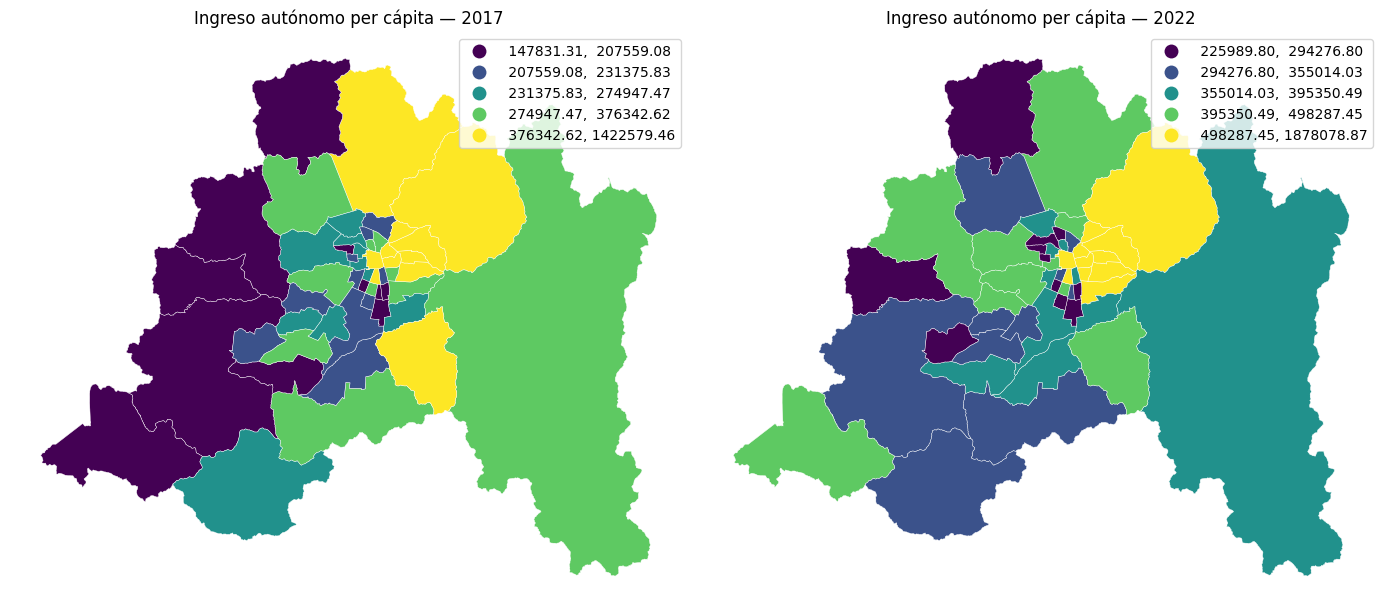

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
gdf.plot(column="ypc_aut_2017", scheme="Quantiles", k=5,
         legend=True, ax=axes[0], cmap="viridis", edgecolor="white", linewidth=0.3)
axes[0].set_title("Ingreso autónomo per cápita — 2017")
axes[0].set_axis_off()

gdf.plot(column="ypc_aut_2022", scheme="Quantiles", k=5,
         legend=True, ax=axes[1], cmap="viridis", edgecolor="white", linewidth=0.3)
axes[1].set_title("Ingreso autónomo per cápita — 2022")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 10. Exportar GeoPackage

In [10]:
gdf.to_file(SALIDA, driver="GPKG")
print(f"Guardado: {SALIDA}")
print(f"Tamaño: {SALIDA.stat().st_size / 1024:.1f} KB")

Guardado: /Users/calipsotornasol/Documents/geodata/datos/external/casen_rm/casen_rm_comunas.gpkg
Tamaño: 2364.0 KB


## Listo

En el notebook de actividad pueden cargar el dataset así:

```python
import geopandas as gpd
gdf = gpd.read_file("datos/external/casen_rm/casen_rm_comunas.gpkg")
```

Columnas disponibles:
- `cod_comuna`, `nom_comuna`, `nom_prov`, `region`
- `ypc_aut_2017`, `ypc_aut_2022` — ingreso autónomo per cápita (pre-transferencias)
- `ypc_tot_2017`, `ypc_tot_2022` — ingreso total per cápita (post-transferencias)
- `mediana_aut_2017`, `mediana_aut_2022` — medianas (más robustas a outliers)
- `n_2017`, `n_2022` — tamaño muestral CASEN por comuna
- `geometry` — polígono comunal en EPSG:32719